
## Cell filtering by size and nuclear intensity

Next we want to streamline the process of size and nuclear intensity filtering with minimal dependencies. It will allow you to visually inspect your filters and make informed decisions about which cells to kick out.


In [1]:
# import required packages

import os
import random
import pandas as pd
import numpy as np
import seaborn as sns 
from matplotlib import pyplot as plt
import pyarrow
from skimage.io  import imread, imsave
import skimage.io

In [2]:
# load in your dataframe - Use dataframe you will export in "cell_table_export"
# set up the base directory
base_dir = "/Users/amir/analysis"
project = "CRC_CellTable_v2"
experiment_id = project
csv_file = "cell_table_size_normalized.csv"

file_path = os.path.join(base_dir, experiment_id, 'segmentation', 'cell_table', csv_file)
df = pd.read_csv(file_path)

# define directories where segmasks, visualization and cell_tables lie
image_dir = os.path.join(base_dir, experiment_id, "image_data")
segmentation_dir = os.path.join(base_dir, experiment_id, "segmentation")
cellpose_output_dir = os.path.join(segmentation_dir, "cellpose_output")
viz_dir = os.path.join(segmentation_dir, "cellpose_visualization")
cell_table_dir = os.path.join(segmentation_dir, "cell_table")

(5000.0, 50000.0)

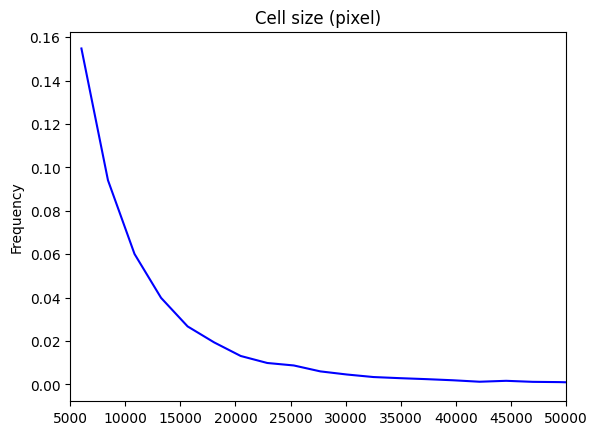

In [3]:
# look at upper cell size increments to get a feeling for the size distribultion in your dataset

# Plot the histogram
histo, bin_edges = np.histogram(df.cell_size, bins=300)
histo = histo/histo.max()
bin_mean = np.convolve(bin_edges, np.ones(2)/2, mode='valid')
fig, ax = plt.subplots()  # Create a figure containing a single axes.
ax.plot( bin_mean[2:], histo[2:], c='b' )
ax.set_title('Cell size (pixel)')
ax.set_ylabel('Frequency')
ax.set_xlim(5000, 50000)
#plt.plot( x, double_gaussian( x, fit[0] ), c='r' )

#### Determine size cutoffs


In [22]:
# define a function that maps size attributes to cells depending on their size
def determine_size_attribute(cell_size): 
    if cell_size < excluded_sizes[0]:
        return 'too_small'
    elif cell_size > excluded_sizes[1]:
        return 'too_large'
    else:
        return 'pass'
    
tested_size_threshold = [0.3, 0.998] # lower/higher exclusion percentile threshold 
fov_list = list(os.listdir(image_dir)) # define a list containing the FOV-names
fov_list = [x for x in fov_list if not x.startswith('.') and os.path.isdir(os.path.join(image_dir, x))] # filter for hidden files and directories only
size_exclusion_viz_dir = os.path.join(base_dir, experiment_id, "size_filtered_viz") # define an output directory for your size-filtered visualizations
os.makedirs(size_exclusion_viz_dir, exist_ok= True)

# Apply the above function to create the size_attribute column for a copy of your dataframe, called "df_size_exclusion"
excluded_sizes = [5000, 40000] # define the lower and upper size threshold for your dataset
df['size_attribute'] = df['cell_size'].apply(determine_size_attribute)
df = df.loc[df['mask_type'] == 'whole_cell']


size_attribute
pass         13574
too_small     8024
too_large      539
Name: count, dtype: int64

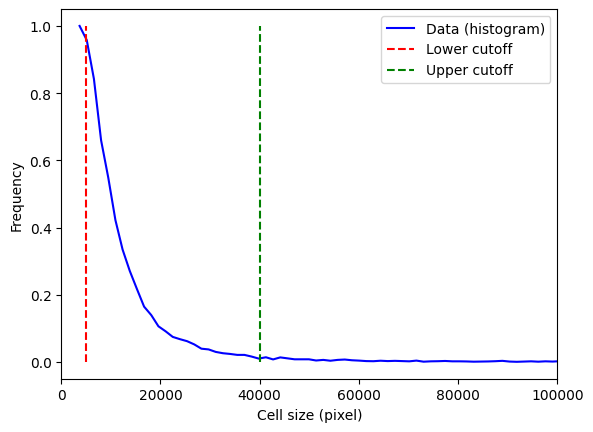

In [40]:
# Plot the histogram
histo, bin_edges = np.histogram(df.cell_size, bins=500)
histo = histo/histo.max()
bin_mean = np.convolve(bin_edges, np.ones(2)/2, mode='valid')
fig, ax = plt.subplots()  # Create a figure containing a single axes.
ax.plot( bin_mean[2:], histo[2:], c='b', label='Data (histogram)' )
ax.set_ylabel('Frequency')
ax.set_xlabel('Cell size (pixel)')
ax.set_xlim(0, 100000)

ymax = histo[2:].max()
ax.vlines( excluded_sizes[0], 0,ymax, colors='r', linestyles='dashed', label='Lower cutoff' )
ax.vlines( excluded_sizes[1], 0,ymax, colors='g', linestyles='dashed', label='Upper cutoff' )
ax.legend()

# check if everything worked proper
df.size_attribute.value_counts()

Idealy, the histogram should have three two peaks. The first peak from the left is the very small cells. They could be a result of tissue cutting or over-segmentation and should be removed. The second peak is the normal size cells but also has a long tail on the right. It is made up of outliers and should be removed. Try to modify the `tested_size_threshold` until you place the lower cutoff at the velley between peaks and the upper cutoff at the begining of the flat part of the tail.

#### We now want to also filter **size adjusted nuclear intensity.**

We want to filter cells by setting a lower threshold on "normalized nuclear expression", the area-corrected nuclear signal per cell.
Artefacts should be low in nuclear signal and thus be eligible for filtering.

In [41]:
# define nuclear intensity column

df["sizenorm_nuclei"] = df.cell_size * df.HH3

### Data transformation to have more normal distributionsnuclei

In [42]:
qt = 0.999 # The quantifle to be normalized to 1
cf = 1000000
column_name = 'sizenorm_nuclei'

qt_v = np.nanpercentile(df[column_name],qt*100)
df[column_name+'_qt_norm'] = df[column_name]/qt_v
# df_all.loc[df[column_name] > 1, [column_name]] = 1
df[column_name+'_arcsinh'] = np.arcsinh(df[column_name+'_qt_norm']*cf)

Text(0, 0.5, 'frequency')

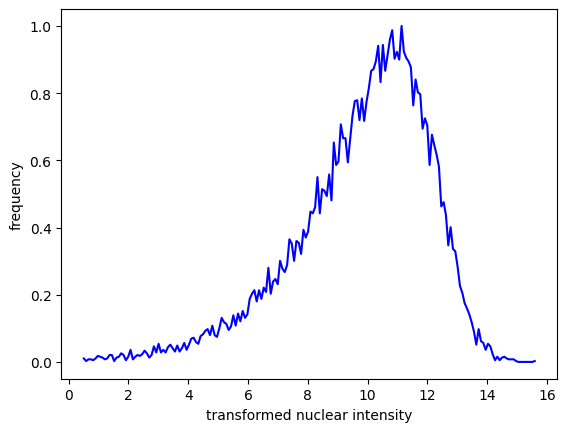

In [43]:
# Plot the histogram
histo, bin_edges = np.histogram(df.sizenorm_nuclei_arcsinh[~np.isnan(df.sizenorm_nuclei_arcsinh)], bins=200)
histo = histo/histo.max()
bin_mean = np.convolve(bin_edges, np.ones(2)/2, mode='valid')

histo = histo[bin_mean>0.5]
histo = histo/histo.max()
bin_mean = bin_mean[bin_mean>0.5]

plt.plot( bin_mean, histo, c='b' )
plt.xlabel('transformed nuclear intensity')
plt.ylabel('frequency')
#plt.plot( x, double_gaussian( x, fit[0] ), c='r' )

#### Determine the threshold by fitting double Gaussian
Two Gaussian functions describing the nuclei-positive and -negative cell populations respectively 

In [44]:
from sklearn import mixture
# import matplotlib.mlab
import numpy as np
from pylab import *
from skimage.io  import imread, imsave
from scipy.optimize import least_squares

In [45]:
# https://stackoverflow.com/questions/33178790/how-to-fit-a-double-gaussian-distribution-in-python

def double_gaussian( bin_mean, params ):
    (c1, mu1, sigma1, c2, mu2, sigma2) = params
    res =   c1 * np.exp( - (bin_mean - mu1)**2.0 / (2.0 * sigma1**2.0) ) \
          + c2 * np.exp( - (bin_mean - mu2)**2.0 / (2.0 * sigma2**2.0) )
    return res

def gaussian( bin_mean, params ):
    (c1, mu1, sigma1) = params
    res =   c1 * np.exp( - (bin_mean - mu1)**2.0 / (2.0 * sigma1**2.0) )
    return res

def double_gaussian_fit( params ):
    fit = double_gaussian( bin_mean, params )
    return (fit - y_proc)

# Remove background.
y_proc = np.copy(histo)
# y_proc[y_proc < 5] = 0.0

    
# Estimate the parameters of the double guassian
bin_range = np.max(bin_mean)-np.min(bin_mean)
peak_1_x = np.min(bin_mean) + 0.25 * bin_range
peak_2_x = np.max(bin_mean) - 0.25 * bin_range


In [46]:
fit = least_squares( double_gaussian_fit, [1,2,2,1,3,1], bounds=(0, np.inf))

# Solve the intersection of the two peaks
x = np.linspace(bin_mean[0],bin_mean[-1],1000)
f = gaussian( x, fit.x[0:3] )
g = gaussian( x, fit.x[3:6] )

idxs=np.argwhere(np.diff(np.sign(f - g))).flatten()
intersect = np.min(x[idxs])
gaussian_val = gaussian(intersect, fit.x[0:3])

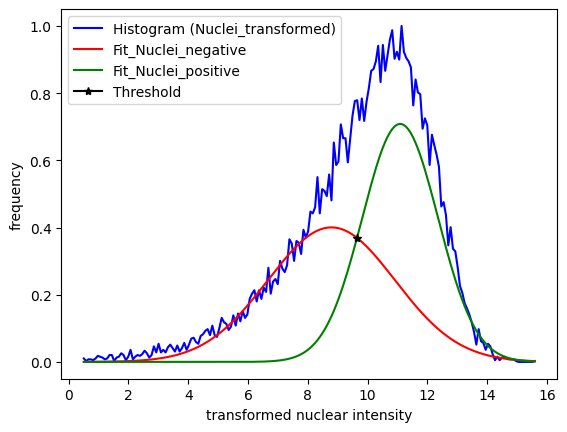

In [47]:
plt.plot( bin_mean, y_proc, c='b', label='Histogram (Nuclei_transformed)' )
plt.plot( bin_mean, gaussian( bin_mean, fit.x[0:3] ), c='r', label='Fit_Nuclei_negative' )
plt.plot( bin_mean, gaussian( bin_mean, fit.x[3:6] ), c='g', label='Fit_Nuclei_positive' )
plt.plot( intersect, gaussian_val, c='k', marker = '*', label='Threshold' )
plt.xlabel('transformed nuclear intensity')
plt.ylabel('frequency')
plt.legend()

The crossing point of the two Gaussian is then determined as the threshold. To make the threshold more transferable to other dataset, let's reverse transform it to the raw size-normalized nuclear intensity.

In [48]:
 # Reverse transform: mapping the transformed value back the the raw
threshold_Nu_raw = np.sinh(intersect)/cf*qt_v # Change it to a specific number if the approach above is not working
print('The threshold of the raw intensity determined by the fit is {0:.2f}. The threshold of your choice is {0:.2f}.'.format(np.sinh(intersect)/cf*qt_v, threshold_Nu_raw))

The threshold of the raw intensity determined by the fit is 6.53. The threshold of your choice is 6.53.


#### Assign the nuclei attributes


In [49]:
# define a function that maps size attributes to cells depending on their size
def determine_Nu_attribute(sizenorm_nuclei): 
    if sizenorm_nuclei < threshold_Nu_raw:
        return 'low_nucleus_intensity'
    else:
        return 'pass'

# Apply the above function to create the size_attribute column for a copy of your dataframe, called "df_size_exclusion"
df['nuclei_attribute'] = df['sizenorm_nuclei'].apply(determine_Nu_attribute)


### Proportion of nucleus

In [50]:
# Calculate proportion of nucleus per cell
df['nucleus_prop'] = df.nucleus_area/df.cell_size

Text(0, 0.5, 'frequency')

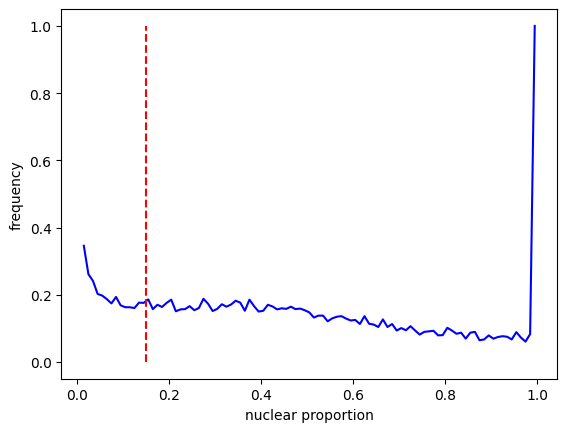

In [51]:
# Plot the histogram
nuc_prop_cutoff = 0.15

histo, bin_edges = np.histogram(df.nucleus_prop[~np.isnan(df.nucleus_prop)], bins=100)
histo = histo/histo.max()
bin_mean = np.convolve(bin_edges, np.ones(2)/2, mode='valid')

histo = histo[bin_mean>0.01]
histo = histo/histo.max()
bin_mean = bin_mean[bin_mean>0.01]

fig, ax = plt.subplots()  # Create a figure containing a single axes.
ax.plot( bin_mean, histo, c='b', label='Data (histogram)' )
ax.vlines( nuc_prop_cutoff, 0,1, colors='r', linestyles='dashed', label='Lower cutoff' )

ax.set_xlabel('nuclear proportion')
ax.set_ylabel('frequency')
#plt.plot( x, double_gaussian( x, fit[0] ), c='r' )

#### Assign the nuclei attributes


In [52]:
# define a function that maps size attributes to cells depending on their size
def determine_Nu_prop_attribute(nucleus_prop): 
    if nucleus_prop < nuc_prop_cutoff:
        return 'low_nuclear_propotion'
    else:
        return 'pass'

# Apply the above function to create the size_attribute column for a copy of your dataframe, called "df_size_exclusion"
df['nuclei_prop_attribute'] = df['nucleus_prop'].apply(determine_Nu_prop_attribute)


### Annotate cells with their filtering status
Here we save the filtering status as cell populations that can be displayed in Mantis viewer

In [53]:
df_attr = df.loc[:,['fov', 'label', 'size_attribute', 'nuclei_attribute','nuclei_prop_attribute']]
df_attr = df_attr.melt(id_vars=['fov', 'label'], value_vars=['size_attribute', 'nuclei_attribute','nuclei_prop_attribute']).drop(columns=['variable'])
df_attr.label = df_attr.label.astype(int)
df_attr = df_attr.loc[~df_attr.value.isin(['pass']), :]
df_attr.to_csv(os.path.join(cell_table_dir, 'cell_filtering_status.csv'), index=False,header=False)
print('The cell_filtering_status.csv file has been save in {0}.'.format(cell_table_dir))

The cell_filtering_status.csv file has been save in /Users/amir/analysis/CRC_CellTable_v2/segmentation/cell_table.


#### Checking the cell filtering in the Mantis viewer
Please load the cell_filtering_status.csv into Mantis viwer through "File->Import->Populations->For project from single csv" and inspect the filtering. **If you are not happy with the result, you can set the `threshold_Nu_raw` above manually and repeat the process.** Otherwise, you can now export the filtered cell table and delete the filtered cells from the segmentation mask.

In [54]:
df_pass = df[~(df.set_index(['label','fov']).index.isin(df_attr.set_index(['label','fov']).index))]
df_pass = df_pass.drop(['size_attribute','sizenorm_nuclei','sizenorm_nuclei_qt_norm','sizenorm_nuclei_arcsinh','nuclei_attribute','nuclei_prop_attribute'], axis = 1)
df_pass.to_csv(os.path.join(cell_table_dir, 'cell_table_size_normalized_filtered.csv'),
                                  compression=None, index=False)

### Delete filtered cells from the segmentation mask
As a last step in this preprocessing script, let's delete the filtered cells from the segmentation mask.

In [55]:
# this function takes two lists as input (unique values in every segmentation mask as list1 and all post-filtering cell labels of the same fov as list2) and finds the difference.

def find_excluded_cells(list1, list2):
    set1 = set(list1)
    set2 = set(list2)

    # Find items that occur in only one of the sets
    unique_items = list(set1.symmetric_difference(set2))

    return unique_items

# this function will delete the filtered cell IDs per fov from the segmentation mask.

def delete_cells_from_mask(array, items_to_zero):
    # Convert the list of items to a set for efficient membership testing
    items_to_zero_set = set(items_to_zero)
    
    # Create a boolean mask indicating whether each element is in the set
    mask = np.isin(array, list(items_to_zero_set))
    
    # Set elements that occur in the set to 0
    array[mask] = 0
    
    return array

In [56]:
# This codeblock will go through all FOVs and clean up their segmentation masks, which will be saved to cleaned_seg_dir.

cleaned_seg_dir = os.path.join(segmentation_dir, "cleaned_segmasks")
os.makedirs(cleaned_seg_dir, exist_ok= True)

for fov in fov_list:
    segmask = np.array(imread(os.path.join(segmentation_dir,"cellpose_output", f"{fov}_whole_cell.tiff")))
    list1 = list(np.unique(segmask))
    list2 = list(df_pass.loc[df_pass["fov"] == fov,:].set_index(['label',]).index)
    deleted_cells = find_excluded_cells(list1, list2)
    cleaned_mask = delete_cells_from_mask(segmask, deleted_cells)
    imsave(os.path.join(cleaned_seg_dir, f"{fov}_cleaned_mask.tiff"), cleaned_mask, check_contrast=False)
    print(f"Mask of {fov} cleaned.")

print("Cleaning completed.")

Mask of B_2b_C01_R01 cleaned.
Mask of A_3n_C01_R01 cleaned.
Mask of B_8k_C01_R01 cleaned.
Mask of A_8r_C01_R01 cleaned.
Mask of B_6o_C01_R01 cleaned.
Mask of B_7o_C01_R01 cleaned.
Mask of C_5f_C01_R01 cleaned.
Mask of A_4e_C01_R01 cleaned.
Mask of A_5p_C01_R01 cleaned.
Mask of C_3m_C01_R01 cleaned.
Mask of C_6a_C01_R01 cleaned.
Mask of A_4q_C01_R01 cleaned.
Mask of A_5q_C01_R01 cleaned.
Mask of B_9c_C01_R01 cleaned.
Mask of E_5c_C01_R01 cleaned.
Mask of B_6r_C01_R01 cleaned.
Mask of A_8f_C01_R01 cleaned.
Mask of B_2c_C01_R01 cleaned.
Mask of A_2o_C01_R01 cleaned.
Mask of A_4m_C01_R01 cleaned.
Mask of C_3e_C01_R01 cleaned.
Mask of B_7n_C01_R01 cleaned.
Mask of B_6n_C01_R01 cleaned.
Mask of C_4g_C01_R01 cleaned.
Mask of A_7b_C01_R01 cleaned.
Mask of A_3d_C01_R01 cleaned.
Mask of B_3h_C01_R01 cleaned.
Mask of A_5f_C01_R01 cleaned.
Mask of B_1g_C01_R01 cleaned.
Mask of B_6p_C01_R01 cleaned.
Mask of B_7e_C01_R01 cleaned.
Mask of A_5o_C01_R01 cleaned.
Mask of B_9h_C01_R01 cleaned.
Mask of A_

In [ ]:
csv_path = os.path.join(cell_table_dir, 'cell_table_size_normalized_filtered.csv')

if os.path.exists(csv_path):
    df_final = pd.read_csv(csv_path)
    print(f"Total cells (rows): {len(df_final)}")
    if 'label' in df_final.columns:
        print(f"Unique labels: {df_final['label'].nunique()}")
    if 'fov' in df_final.columns:
        print(f"Unique FOVs: {df_final['fov'].nunique()}")
else:
    print("File not found:", csv_path)